<a href="https://colab.research.google.com/github/Rodrivdlc/Sistema-basado-en-Inteligencia-Artificial-para-la-detecci-n-de-enfermedades-en-cultivos/blob/main/notebooks/02_preparacion_dataset_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import tensorflow as tf

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/TFG/dataset/archive.zip" -d "/content/dataset"

In [ ]:
dataset_path = "/content/dataset/PlantVillage"

In [ ]:
clases = os.listdir(dataset_path)

clases_tomate = [
    clase for clase in clases
    if clase.lower().startswith("tomato")
]

print(clases_tomate)

['Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Leaf_Mold', 'Tomato_healthy', 'Tomato_Early_blight', 'Tomato_Septoria_leaf_spot', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato_Late_blight']


In [ ]:
import shutil

tomato_path = "/content/tomato_dataset"

os.makedirs(tomato_path, exist_ok=True)

In [ ]:
for clase in clases_tomate:
    origen = os.path.join(dataset_path, clase)
    destino = os.path.join(tomato_path, clase)

    if not os.path.exists(destino):
        shutil.copytree(origen, destino)

In [ ]:
print(os.listdir(tomato_path))

['Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Leaf_Mold', 'Tomato_healthy', 'Tomato_Early_blight', 'Tomato_Septoria_leaf_spot', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato_Late_blight']


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    tomato_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 16011 files belonging to 10 classes.
Using 12809 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    tomato_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 16011 files belonging to 10 classes.
Using 3202 files for validation.


In [ ]:
class_names = train_ds.class_names

print("Clases:")
for i, clase in enumerate(class_names):
    print(i, clase)

Clases:
0 Tomato_Bacterial_spot
1 Tomato_Early_blight
2 Tomato_Late_blight
3 Tomato_Leaf_Mold
4 Tomato_Septoria_leaf_spot
5 Tomato_Spider_mites_Two_spotted_spider_mite
6 Tomato__Target_Spot
7 Tomato__Tomato_YellowLeaf__Curl_Virus
8 Tomato__Tomato_mosaic_virus
9 Tomato_healthy


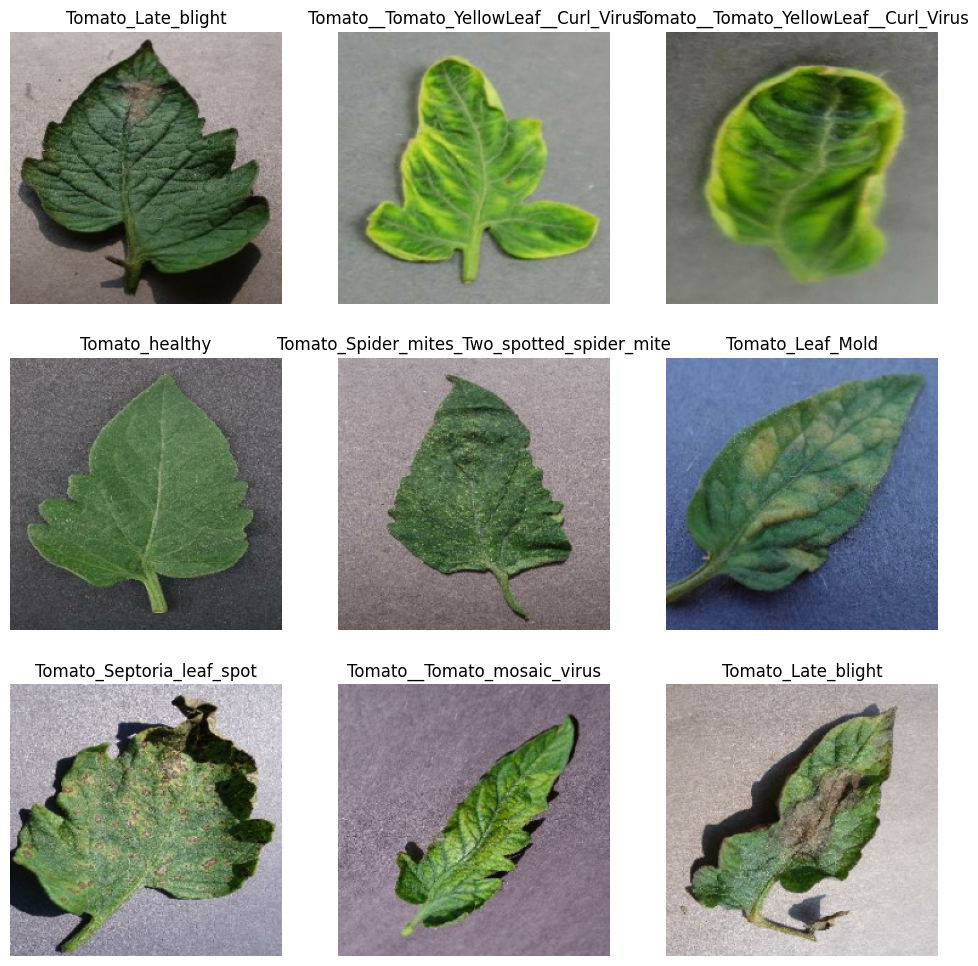

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
import os
import shutil
import random

In [ ]:
source_path = "/content/tomato_dataset"

split_base = "/content/tomato_split"

train_path = os.path.join(split_base, "train")
val_path = os.path.join(split_base, "val")
test_path = os.path.join(split_base, "test")

In [ ]:
for ruta in [train_path, val_path, test_path]:
    os.makedirs(ruta, exist_ok=True)

In [ ]:
random.seed(42)

for clase in os.listdir(source_path):
    clase_path = os.path.join(source_path, clase)

    if not os.path.isdir(clase_path):
        continue

    imagenes = [
        img for img in os.listdir(clase_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(imagenes)

    total = len(imagenes)

    train_end = int(total * 0.70)
    val_end = int(total * 0.85)

    train_imgs = imagenes[:train_end]
    val_imgs = imagenes[train_end:val_end]
    test_imgs = imagenes[val_end:]

    for destino_base, lista in [
        (train_path, train_imgs),
        (val_path, val_imgs),
        (test_path, test_imgs)
    ]:
        destino_clase = os.path.join(destino_base, clase)
        os.makedirs(destino_clase, exist_ok=True)

        for imagen in lista:
            shutil.copy2(
                os.path.join(clase_path, imagen),
                os.path.join(destino_clase, imagen)
            )

In [ ]:
def contar_imagenes(ruta):
    total = 0

    for clase in os.listdir(ruta):
        clase_path = os.path.join(ruta, clase)

        if os.path.isdir(clase_path):
            total += len([
                img for img in os.listdir(clase_path)
                if img.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

    return total


print("Train:", contar_imagenes(train_path))
print("Validation:", contar_imagenes(val_path))
print("Test:", contar_imagenes(test_path))

Train: 11203
Validation: 2402
Test: 2406


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 11203 files belonging to 10 classes.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2402 files belonging to 10 classes.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2406 files belonging to 10 classes.


In [ ]:
class_names = train_ds.class_names

print(class_names)

['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)